In [322]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [323]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)

<Axes: >

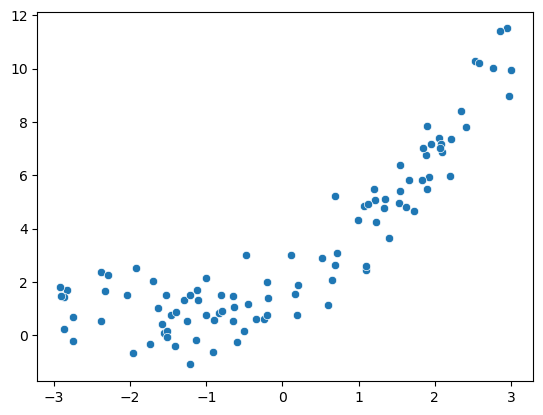

In [324]:
sns.scatterplot(x=X.flatten(), y=y.flatten())

In [325]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Simple Linear Regression

In [326]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [327]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


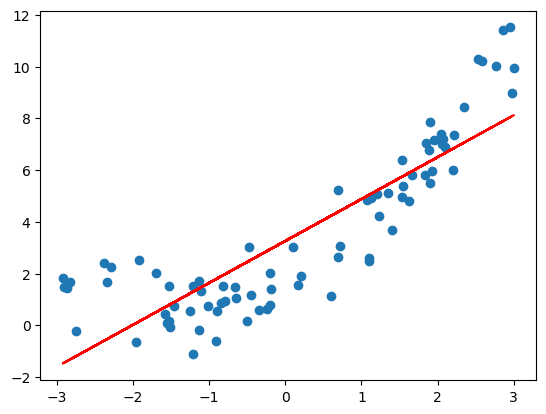

In [328]:
## Plot Training data plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color='r')

In [329]:
y_pred = lr.predict(X_test)
print(y_pred)

[[ 0.44151718]
 [ 4.31414518]
 [-1.39582603]
 [-0.05466135]
 [ 0.99227357]
 [ 0.97622376]
 [ 4.09704473]
 [-0.61188839]
 [-1.19929649]
 [ 1.6226411 ]
 [ 4.85456811]
 [ 1.16200454]
 [ 0.61770948]
 [ 5.41264169]
 [ 6.05536266]
 [ 2.28451175]
 [ 3.56362576]
 [ 2.20184361]
 [ 5.21099753]
 [ 7.16379435]]


In [330]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 1.994775604089946
Mean Absolute Error: 1.1793127723637724
Root Mean Squared Error: 1.412365251657639
R2 score: 0.5867799431937408
Adjusted R2 score: 0.5638232733711709


## Simple Polynomial Regression

In [331]:
## apply polynomial transformation with degree=2
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=True)

In [332]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [333]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [334]:
y_pred = lr.predict(X_test_poly)

In [335]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 0.8280362739702654
Mean Absolute Error: 0.811340142121477
Root Mean Squared Error: 0.909964985024295
R2 score: 0.8284713350884715
Adjusted R2 score: 0.8189419648156088


In [336]:
print(lr.coef_)

[[0.         1.50641241 0.52422877]]


In [337]:
print(lr.intercept_)

[1.73985524]


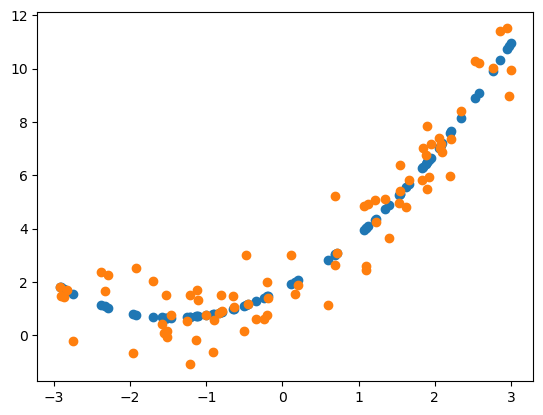

In [338]:
plt.scatter(x=X_train, y=lr.predict(X_train_poly))
plt.scatter(x=X_train, y=y_train)

In [339]:
## apply polynomial transformation with degree=2
poly2 = PolynomialFeatures(degree=3, include_bias=True)

X_train_poly = poly2.fit_transform(X_train)
X_test_poly = poly2.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred = lr.predict(X_test_poly)

## Performance Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 0.8181424828608629
Mean Absolute Error: 0.807742477770318
Root Mean Squared Error: 0.9045122900551782
R2 score: 0.8305208452769228
Adjusted R2 score: 0.8211053366811963


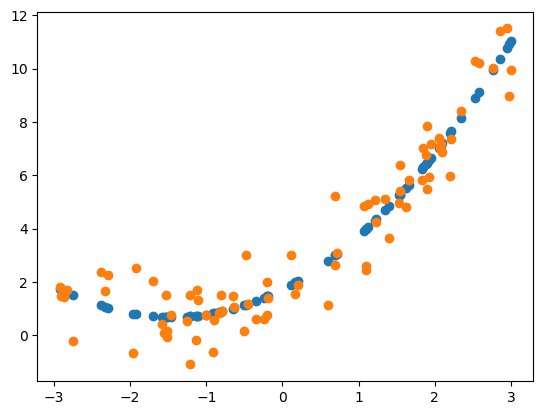

In [340]:
plt.scatter(x=X_train, y=lr.predict(X_train_poly))
plt.scatter(x=X_train, y=y_train)

In [341]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

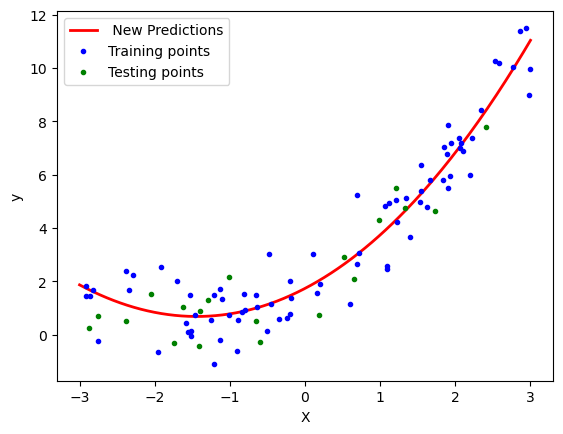

In [342]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_new = lr.predict(poly2.transform(X_new))
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [343]:
from sklearn.pipeline import Pipeline

In [344]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

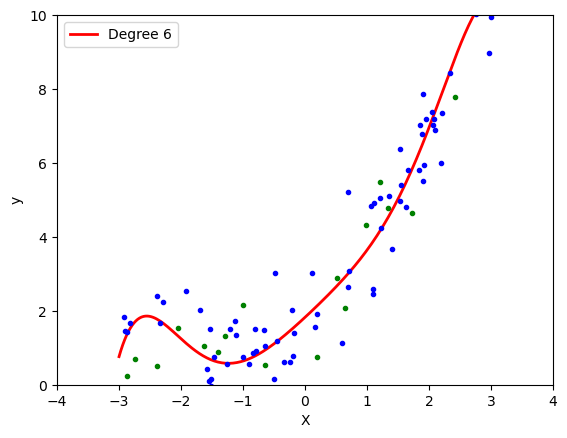

In [345]:
poly_regression(6)